# Problem Type : Classification

# Task : Predict Employee Leaving

**Target Column: Attrition (Stayed / Left)**

Your dataset contains **14,900 rows × 24 columns.**

```
Target Variable: Attrition

Classes: Stayed = 0
         Left = 1
```

# **Step 1: Import Required Libraries**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# **Step 2: Load Dataset**
**Read CSV File**

In [2]:
df = pd.read_csv('/content/Employee Attrition Dataset.csv')

print(df.shape)

df.head()

(14900, 24)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


# **Step 3: Basic Dataset Information**
**Check Structure**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               14900 non-null  int64 
 1   Age                       14900 non-null  int64 
 2   Gender                    14900 non-null  object
 3   Years at Company          14900 non-null  int64 
 4   Job Role                  14900 non-null  object
 5   Monthly Income            14900 non-null  int64 
 6   Work-Life Balance         14900 non-null  object
 7   Job Satisfaction          14900 non-null  object
 8   Performance Rating        14900 non-null  object
 9   Number of Promotions      14900 non-null  int64 
 10  Overtime                  14900 non-null  object
 11  Distance from Home        14900 non-null  int64 
 12  Education Level           14900 non-null  object
 13  Marital Status            14900 non-null  object
 14  Number of Dependents  

In [4]:
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,14900.000000,14900.000000,14900.000000,14900.000000,14900.000000,14900.000000,14900.000000,14900.000000
mean,37339.022081,38.385235,15.592416,7287.306040,0.834362,49.927315,1.659329,55.603624
std,21453.129293,12.097904,11.133792,2156.737934,0.996511,28.702307,1.545401,25.352807
min,5.000000,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000,2.000000
25%,18825.500000,28.000000,7.000000,5633.750000,0.000000,25.000000,0.000000,36.000000
50%,37433.000000,38.000000,13.000000,7332.000000,1.000000,50.000000,1.000000,56.000000
75%,55857.500000,49.000000,23.000000,8852.000000,2.000000,75.000000,3.000000,75.000000
max,74471.000000,59.000000,51.000000,15063.000000,4.000000,99.000000,6.000000,127.000000


In [5]:
df.isnull().sum()

,0
Employee ID,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0


# **Step 4: Exploratory Data Analysis (EDA)**
**Target Variable Distribution**

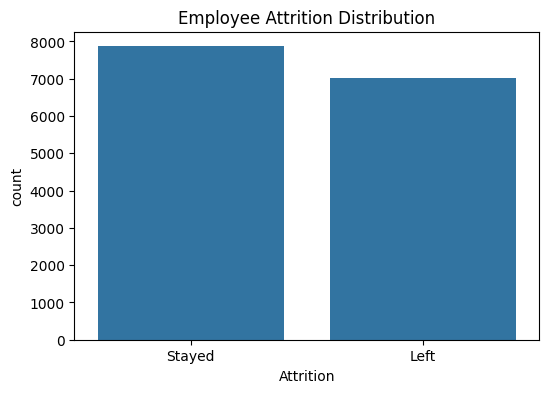

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Attrition',
    data=df
)

plt.title("Employee Attrition Distribution")
plt.show()

**Pie Chart**

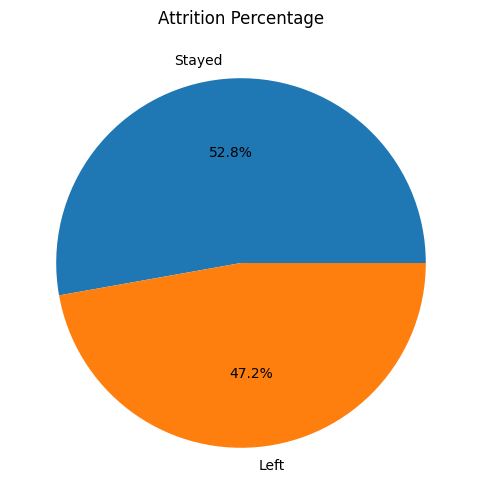

In [7]:
df['Attrition'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Attrition Percentage")
plt.ylabel('')
plt.show()

# **Step 5: Remove Unnecessary Column**

Employee ID prediction me useful nahi hai.

In [10]:
df.drop("Employee ID", axis=1, inplace=True)

# **Step 6: Encode Target Variable**
Convert:

In [11]:
Stayed = 0
Left = 1

In [12]:
target_encoder = LabelEncoder()

df['Attrition'] = target_encoder.fit_transform(df['Attrition'])

print(df['Attrition'].unique())

[1 0]


# **Step 7: Encode Categorical Columns**

Dataset me multiple categorical columns present hain.

In [13]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# **Step 8: Separate Features and Target**

In [14]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

# **Step 9: Feature Scaling**

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# **Step 10: Train Test Split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(11920, 22)
(2980, 22)


# **Step 11: Build ANN Model**

```
ANN Architecture

Input Layer
↓
Dense Layer (128)
↓
Dropout
↓
Dense Layer (64)
↓
Dropout
↓
Dense Layer (32)
↓
Output Layer
```

In [17]:
model = Sequential()

# Hidden Layer 1
model.add(Dense(
    units=128,
    activation='relu',
    input_dim=X_train.shape[1]
))

model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(
    units=64,
    activation='relu'
))

model.add(Dropout(0.3))

# Hidden Layer 3
model.add(Dense(
    units=32,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Step 12: Compile Model**

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

# **Step 13: Early Stopping**

Overfitting avoid karne ke liye.

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# **Step 14: Train ANN Model**

In [24]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7399 - loss: 0.5061 - val_accuracy: 0.7244 - val_loss: 0.5323
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7426 - loss: 0.5053 - val_accuracy: 0.7261 - val_loss: 0.5313
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7382 - loss: 0.5079 - val_accuracy: 0.7202 - val_loss: 0.5331
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7404 - loss: 0.5026 - val_accuracy: 0.7261 - val_loss: 0.5353
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7437 - loss: 0.4987 - val_accuracy: 0.7227 - val_loss: 0.5367
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7469 - loss: 0.4994 - val_accuracy: 0.7202 - val_loss: 0.5301
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7466 - loss: 0.4972 - val_accuracy: 0.7181 - val_loss: 0.5376
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7475 - loss: 0.4956 - val_accu

# **Step 15: Training vs Validation Accuracy Graph**

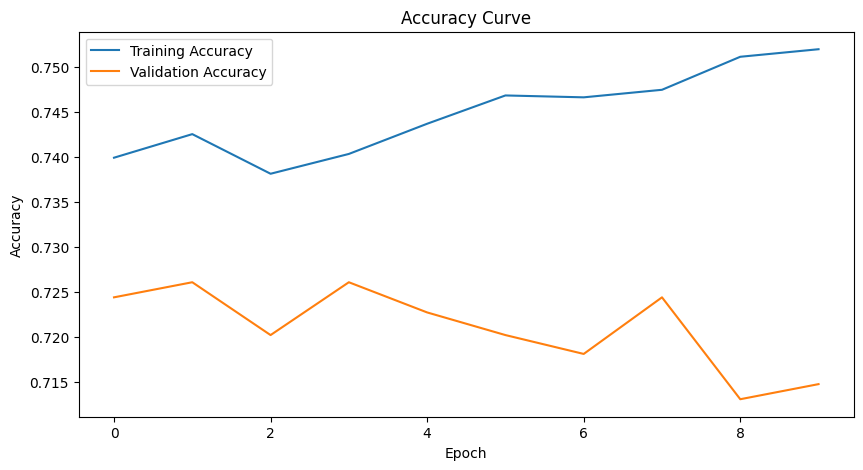

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

# **Step 16: Training vs Validation Loss Graph**

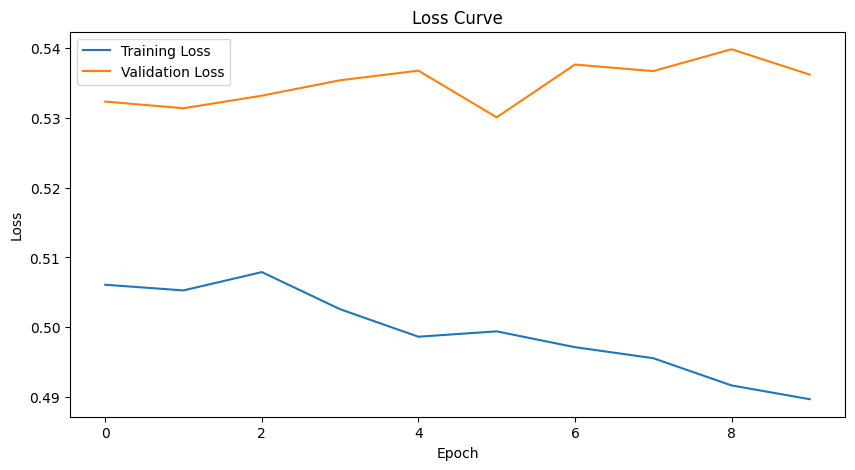

In [26]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Loss Curve')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

# **Step 17: Model Prediction**

In [27]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

y_pred[:10]

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0]])

# **Step 18: Accuracy Score**

In [28]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(accuracy*100,2), "%")

Accuracy : 73.22 %


# **Step 19: Confusion Matrix**

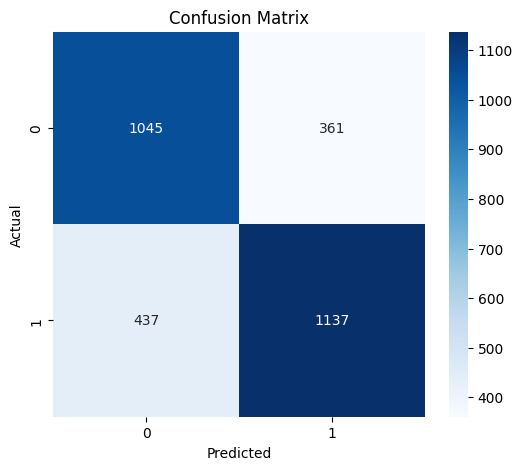

In [29]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **Step 20: Classification Report**

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      0.74      0.72      1406
           1       0.76      0.72      0.74      1574

    accuracy                           0.73      2980
   macro avg       0.73      0.73      0.73      2980
weighted avg       0.73      0.73      0.73      2980



# **Step 21: Predict New Employee Attrition**

In [31]:
new_employee = [[
    35,     # Age
    1,      # Gender
    5,      # Years at Company
    2,      # Job Role
    65000,  # Monthly Income
    3,      # Work-Life Balance
    4,      # Job Satisfaction
    3,      # Performance Rating
    1,      # Overtime
    10,     # Distance From Home
    3,      # Education
    4,      # Environment Satisfaction
    2,      # Training Times Last Year
    1,      # Stock Option Level
    2,      # Years Since Last Promotion
    3,      # Years With Current Manager
    2,      # Job Level
    4,      # Relationship Satisfaction
    1,      # Marital Status
    2,      # Business Travel
    1,      # Department
    2,      # Num Companies Worked
]]

new_employee_scaled = scaler.transform(new_employee)

prediction = model.predict(new_employee_scaled)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[0.9947189]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# **Convert Probability into Class**

In [32]:
if prediction[0][0] > 0.5:
    print("Employee Will Leave Company")
else:
    print("Employee Will Stay")

Employee Will Leave Company
